# Klasifikasi Ikan Berdasarkan Data Numerik

Notebook ini menganalisis dataset `ikan_dataset.csv` yang berisi pengukuran fisik ikan seperti panjang, tinggi, lebar, dan berat untuk mengklasifikasikan jenis ikan (Tuna vs Tongkol).

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import joblib
import os

sns.set(style="whitegrid")

## 2. Load Dataset

In [3]:
df = pd.read_csv('ikan_dataset.csv')
print(f"Shape dataset: {df.shape}")
df.head()

Shape dataset: (50, 12)


,panjang_badan,tinggi_badan,lebar_badan,panjang_kepala,diameter_mata,ukuran_mulut,tinggi_sirip,berat,jumlah_sisik,intensitas_warna,usia,jenis_ikan
0,45.2,12.5,8.3,9.5,1.20,3.2,6.5,2.8,120,78,3,tuna
1,52.1,13.8,9.1,10.2,1.30,3.5,7.2,3.5,128,82,4,tuna
2,48.5,12.9,8.7,9.8,1.15,3.1,6.8,3.0,122,75,3,tuna
3,55.3,14.2,9.5,10.5,1.35,3.6,7.5,3.8,130,85,5,tuna
4,50.7,13.1,8.9,10.0,1.25,3.3,7.0,3.2,125,79,4,tuna


## 3. Exploratory Data Analysis (EDA)

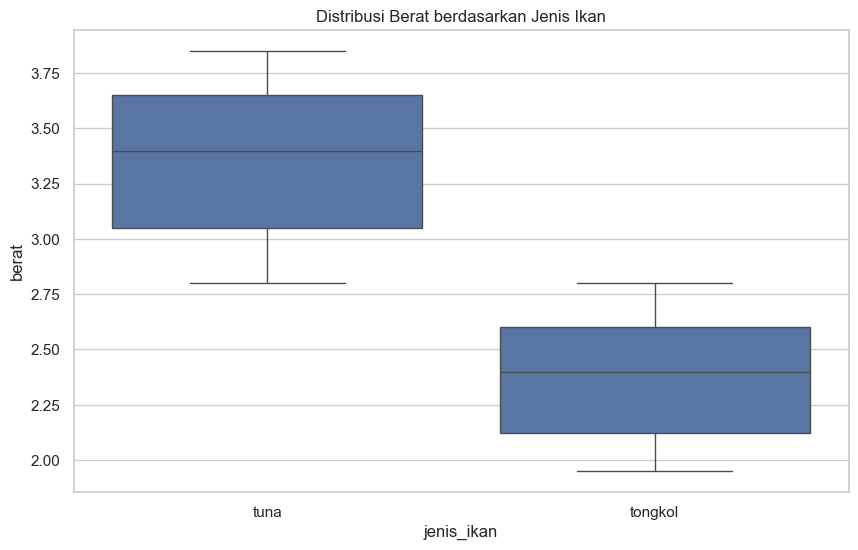

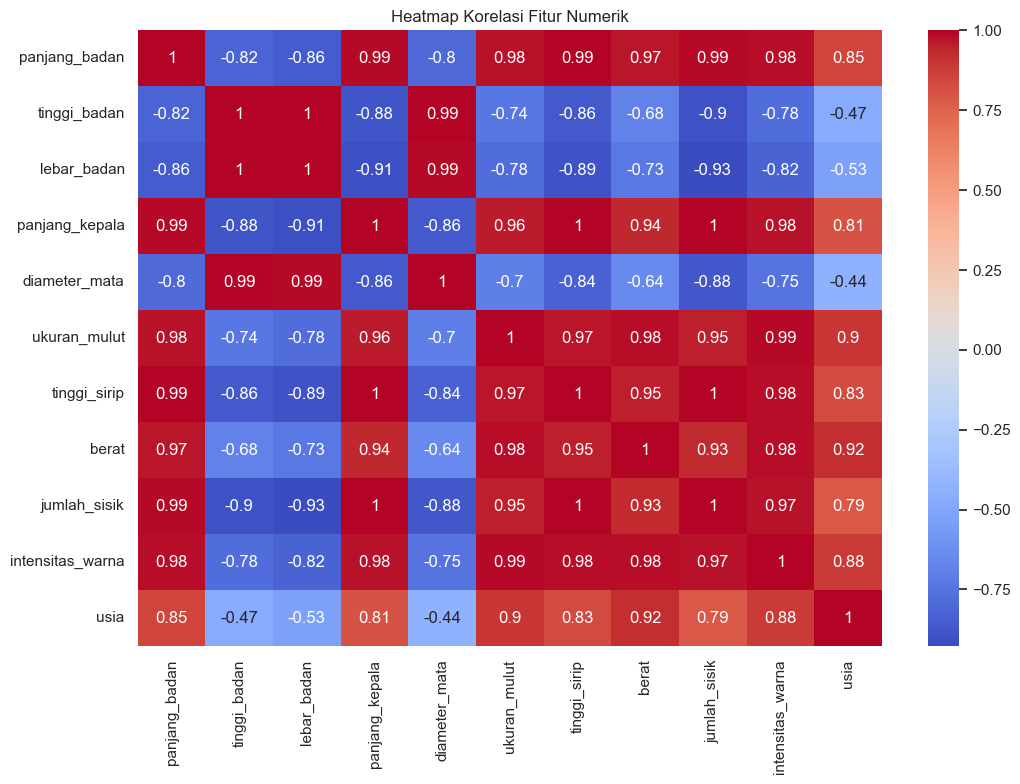

In [4]:
# Visualisasi distribusi berat berdasarkan jenis ikan
plt.figure(figsize=(10, 6))
sns.boxplot(x='jenis_ikan', y='berat', data=df)
plt.title('Distribusi Berat berdasarkan Jenis Ikan')
plt.show()

# Korelasi antar fitur
plt.figure(figsize=(12, 8))
sns.heatmap(df.drop('jenis_ikan', axis=1).corr(), annot=True, cmap='coolwarm')
plt.title('Heatmap Korelasi Fitur Numerik')
plt.show()

## 4. Preprocessing

In [6]:
X = df.drop('jenis_ikan', axis=1)
y = df['jenis_ikan']

# Encoding label
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

# Scaling fitur (penting untuk SVM dan KNN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 5. Modeling

SVM Accuracy: 1.0000
KNN Accuracy: 1.0000
Random Forest Accuracy: 1.0000


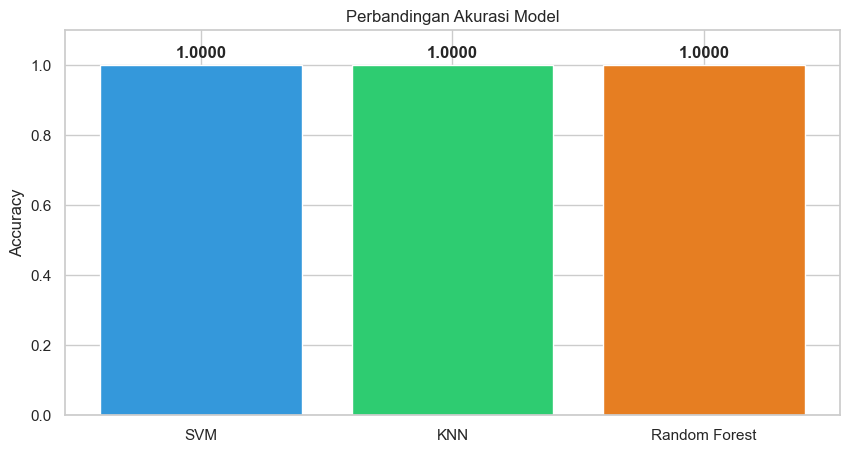

In [7]:
models = {
    "SVM": SVC(probability=True),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Random Forest": RandomForestClassifier(n_estimators=100)
}

results = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"{name} Accuracy: {acc:.4f}")

# Perbandingan visual
plt.figure(figsize=(10, 5))
plt.bar(results.keys(), results.values(), color=['#3498db', '#2ecc71', '#e67e22'])
plt.ylabel('Accuracy')
plt.title('Perbandingan Akurasi Model')
plt.ylim(0, 1.1)
for i, v in enumerate(results.values()):
    plt.text(i, v + 0.02, f"{v:.4f}", ha='center', fontweight='bold')
plt.show()

## 6. Evaluasi Mendalam

Melihat Confusion Matrix dan Classification Report untuk model terbaik (Random Forest).

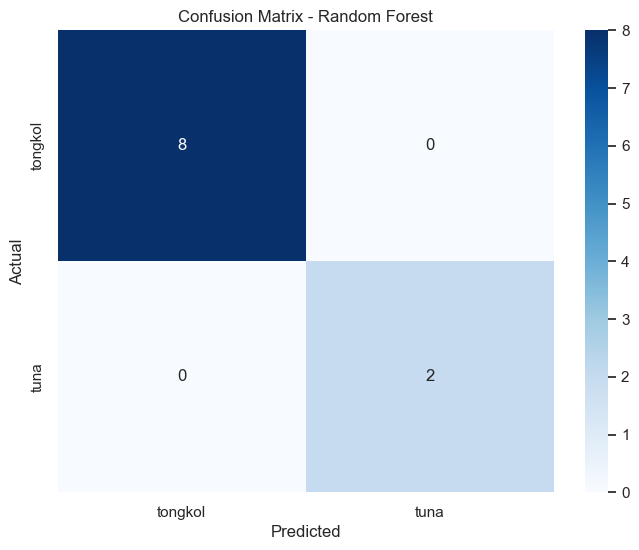


Classification Report:
              precision    recall  f1-score   support

     tongkol       1.00      1.00      1.00         8
        tuna       1.00      1.00      1.00         2

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10



In [8]:
best_model = models["Random Forest"]
y_pred = best_model.predict(X_test_scaled)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Random Forest')
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

## 7. Menyimpan Model

Menyimpan model dan scaler untuk penggunaan di masa depan.

In [9]:
if not os.path.exists('models'):
    os.makedirs('models')

joblib.dump(best_model, 'models/ikan_rf_model_numerik.pkl')
joblib.dump(scaler, 'models/scaler_numerik.pkl')
joblib.dump(le, 'models/label_encoder_numerik.pkl')

print("Model berhasil disimpan di folder 'models/'!")

Model berhasil disimpan di folder 'models/'!


## 8. Uji Prediksi Data Baru

Simulasi prediksi dengan data input baru.

In [11]:
def prediksi_ikan_baru(panjang, tinggi, lebar, p_kepala, d_mata, u_mulut, t_sirip, berat, sisik, warna, usia):
    model = joblib.load('models/ikan_rf_model_numerik.pkl')
    scaler = joblib.load('models/scaler_numerik.pkl')
    le = joblib.load('models/label_encoder_numerik.pkl')
    
    data = np.array([[panjang, tinggi, lebar, p_kepala, d_mata, u_mulut, t_sirip, berat, sisik, warna, usia]])
    data_scaled = scaler.transform(data)
    
    pred_idx = model.predict(data_scaled)[0]
    proba = model.predict_proba(data_scaled)[0][pred_idx]
    hasil = le.classes_[pred_idx]
    
    print(f"\nHasil Prediksi: {hasil.upper()}")
    print(f"Tingkat Keyakinan: {proba*100:.2f}%")

# Contoh Pengujian
print("Menguji dengan data baru (Mirip Tuna):")
prediksi_ikan_baru(35.8,16.2,11.5,7.2,1.5,2.8,5.2,2.1,95,65,2)

Menguji dengan data baru (Mirip Tuna):

Hasil Prediksi: TONGKOL
Tingkat Keyakinan: 100.00%


c:\Users\User\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
